# Learning Probability Distributions with Normalizing Flows

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Companion/cc_normflows/normflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a></div>

Normalizing flows are generative models that learn an invertible transformation between a simple probability distribution and a more complex data distribution.

In this notebook, you'll train a Real-valued Non-Volume Preserving transformation (RealNVP) normalizing flow to model a two-dimensional two-moons distribution. You'll see how invertible neural-network layers deform a Gaussian distribution into the data distribution, how the same model maps data back into a Gaussian latent space, and how the model can be trained by maximizing exact likelihood.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This companion example extends the generative-modeling sequence in <em>Deep Learning Crash Course</em>. It connects most directly to autoencoders (Chapter 4), generative adversarial networks (Chapter 9), and diffusion models (Chapter 10). Unlike those examples, the model here is explicitly invertible and provides an exact likelihood for each data point.

<strong>Deep Learning Crash Course</strong>  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)
</div>

## Understanding Normalizing Flows

Many generative models learn to produce new samples, but they do not always provide an exact probability density. A generative adversarial network can generate realistic samples, but it does not directly tell you the probability of a given input. A variational autoencoder provides a likelihood lower bound, not an exact likelihood. A diffusion model defines a gradual denoising process, but sampling typically requires many iterative steps.

Normalizing flows occupy a unique position among these models. They learn an invertible transformation between a simple latent distribution (typically a Gaussian) and the complex distribution of the data. This allows them to both generate new samples and assign an exact probability density to every sample.


The following table summarizes the main differences.

| Model | Learns latent representation | Exact likelihood | Fast sampling | Invertible | Main idea |
|:------|:----------------------------:|:----------------:|:-------------:|:----------:|:----------|
| Autoencoder | ✓ | ✗ | ✓ | ✗ | Compress and reconstruct data |
| Variational Autoencoder (VAE) | ✓ | Approximate | ✓ | ✗ | Learn a probabilistic latent space |
| GAN | Implicit | ✗ | ✓ | ✗ | Generate samples through adversarial training |
| Diffusion Model | Implicit | Approximate | ✗ | ✗ | Gradually remove noise to generate data |
| **Normalizing Flow** | ✓ | **✓** | **✓** | **✓** | Learn an invertible mapping between a Gaussian and the data distribution |


A normalizing flow starts from a simple latent random variable, typically sampled from a standard multivariate Gaussian distribution,

$$
z \sim \mathcal{N}(0,I),
$$

and learns an invertible transformation

$$
x = f_\theta(z)
$$

that maps this simple latent variable ($z$) to the data space ($x$). Here, $\theta$ denotes the trainable parameters of the model, which are optimized during training to make the transformed distribution match the data distribution.

Because the transformation is invertible, you can also go in the opposite direction:

$$
z = f_\theta^{-1}(x).
$$

This means that the same model can both generate new samples by transforming Gaussian latent variables into the data space and map existing data back into the latent space, where their probability density can be evaluated exactly.

### Transforming Probability Densities

The key mathematical idea behind normalizing flows is the *change-of-variables formula*. It tells you how the probability density changes when you apply an invertible transformation.

To build some intuition, imagine drawing equally spaced dots on a rubber sheet.

- If you stretch one region of the sheet, the dots move farther apart, so their density decreases.

- If you compress another region, the dots move closer together, so their density increases.

A normalizing flow behaves in exactly the same way. As it transforms a simple Gaussian distribution into the data distribution, it continuously stretches and compresses different regions of space. To correctly describe the transformed distribution, you therefore need to account for these local changes in density.

A simple one-dimensional example illustrates this idea. Suppose your transformation simply doubles every coordinate,
$$
x = 2z.
$$
Points become twice as far apart, so the probability density becomes half as large.

Conversely, if
$$
x = \frac{z}{2},
$$
the points become twice as close together, so the density doubles.

In one dimension, the stretching or compression is measured by the derivative of the transformation. In higher dimensions, the corresponding quantity is the *Jacobian determinant*, which measures how the transformation changes the volume of an infinitesimally small region around each point.

Suppose now that a data point $x$ is mapped to its latent representation

$$
z=f_\theta^{-1}(x).
$$

The probability density of the data point is then given by

$$
p_X(x)
=
p_Z(z)
\left|
\det
\frac{\partial z}{\partial x}
\right|,
$$

where

- $p_X(x)$ is the probability density in the data space;

- $p_Z(z)$ is the probability density in the latent space, where we assume a simple Gaussian distribution;

- $\frac{\partial z}{\partial x}$ is the *Jacobian matrix*, which contains the partial derivatives of the transformation;

- $\left|\det \frac{\partial z}{\partial x}\right|$ is the *Jacobian determinant*, which measures how much the transformation locally stretches or compresses space.

### Training a Normalizing Flow

The change-of-variables formula tells you how to compute the probability density of any data point under the model. If the transformation expands a small region, the probability density decreases. If it compresses the region, the probability density increases. The Jacobian determinant provides exactly the correction needed to account for these geometric changes.

In supervised learning, a model is trained to predict the correct labels for a set of training examples. In a normalizing flow, there are no labels. Instead, the goal is to learn a probability distribution that matches the distribution of the training data.

A good model should assign high probability densities to the data it has observed during training. Conversely, if the learned distribution does not yet match the data, many training samples will receive low probability densities. Training therefore consists of adjusting the model parameters, $\theta$, so that the probability density assigned to the training data becomes as large as possible.

Rather than working directly with the probability density, it is more convenient to work with its logarithm. Taking the logarithm of the change-of-variables formula gives
$$
\log p_X(x)
=
\log p_Z(z)
+
\log
\left|
\det
\frac{\partial z}{\partial x}
\right|.
$$
This quantity is called the *log-likelihood*.
The equation has a simple interpretation:

* The first term, $\log p_Z(z)$, measures how likely the transformed point is under the simple Gaussian distribution in the latent space.

* The second term, $\log\left|\det\frac{\partial z}{\partial x}\right|$, corrects this probability to account for the stretching and compression introduced by the transformation.

The objective of training is therefore to *maximize the log-likelihood* of the training data. Since most optimization algorithms are designed to *minimize* a loss function rather than maximize an objective, we instead minimize its negative,
$$
\mathcal{L}
=
-\log p_X(x),
$$
which is called the *negative log-likelihood (NLL)*. Minimizing the NLL is exactly equivalent to maximizing the log-likelihood, and therefore encourages the model to assign high probability densities to the observed training data.

### Why Special Layers Are Needed

A generic neural network can be difficult or impossible to invert. Even if it is invertible, computing the determinant of its Jacobian can be expensive.

Normalizing flows solve this problem by using special invertible layers whose Jacobian determinants are easy to compute. The layer structure is chosen by design, while the details of the transformation are learned from data. In this notebook, you'll implement RealNVP, a flow based on affine coupling layers.

For a two-dimensional input $x=(x_1,x_2)$, a coupling layer can leave one coordinate unchanged and transform the other:
$$
y_1 = x_1
$$
$$
y_2 = x_2 \exp(s(x_1)) + t(x_1)
$$
where $s(\cdot)$ and $t(\cdot)$ are small neural networks. These neural networks are the trainable part of the coupling layer. Given the unchanged coordinate $x_1$, they predict how much the other coordinate should be scaled and shifted. The function $s(x_1)$ controls local stretching or compression, while $t(x_1)$ controls local translation.

During training, the parameters of the neural networks $s$ and $t$ are adjusted so that the transformed data points become likely under the Gaussian latent distribution. At the same time, the coupling-layer structure ensures that the transformation remains exactly invertible and that the log determinant remains easy to compute.

This transformation is easy to invert:
$$
x_1 = y_1
$$
$$
x_2 = \left(y_2 - t(y_1)\right)\exp(-s(y_1))
$$
The Jacobian is triangular, so the log determinant is simply $s(x_1)$. This term is added to the log-likelihood during training, as described above.

A single coupling layer can only transform part of the input. By alternating which coordinate is kept fixed and stacking several coupling layers, the model can learn much richer transformations. In each layer, different neural networks predict the scale and translation, so the full flow becomes a flexible sequence of learned invertible transformations.

Throughout this notebook, you'll use two-dimensional toy datasets because they let us visualize every transformation learned by the model. However, the same architecture extends naturally to higher-dimensional data, including images, where each coupling layer transforms part of the input while using the remaining variables to guide the transformation.

## Defining the Problem

In this notebook, you'll learn a probability distribution rather than predict labels or reconstruct images. A probability distribution describes where data are likely to occur. In this case, it describes where points are located in a two-dimensional plane.

You'll use a synthetic two-moons dataset, shown below. It consists of two interleaving crescent-shaped clusters of points. Although the dataset is simple, it has a curved structure that cannot be described well by a single Gaussian distribution. This makes it an ideal benchmark for normalizing flows, since we can easily visualize both the data and the transformations learned by the model.

The goal is to learn an invertible transformation between two distributions:

- the *data distribution*, represented by the two-moons dataset; and

- a simple *latent distribution*, which we'll choose to be a standard Gaussian distribution.

During training, the model learns how to map points from the two-moons distribution into the Gaussian distribution. Once training is complete, you can reverse this transformation: by sampling random points from the Gaussian distribution and applying the inverse mapping, you generate new samples that follow the two-moons distribution.

As a reference, you'll compare the normalizing flow with a much simpler probabilistic model: a single Gaussian fitted directly to the data. This baseline assumes that the entire dataset can be represented by one elliptical cloud of points. Comparing it with the normalizing flow highlights the advantage of learning a flexible sequence of invertible transformations instead of relying on a fixed probability distribution.

## Generating the Two-Moons Data

The two-moons dataset consists of two curved bands in two dimensions. You can think of each point as one sample from an unknown probability distribution. The model will not use class labels. It only sees the coordinates of the points.

Write a function to generate the two-moons dataset ...

In [1]:
import numpy as np


def make_two_moons(num_samples, noise, seed=0):
    """Generate a two-moons dataset without external dependencies."""

    rng = np.random.default_rng(seed)

    num_moon_1 = num_samples // 2
    num_moon_2 = num_samples - num_moon_1

    theta_moon_1 = rng.uniform(0, np.pi, num_moon_1)
    theta_moon_2 = rng.uniform(0, np.pi, num_moon_2)

    moon_1 = np.stack(
        [np.cos(theta_moon_1), np.sin(theta_moon_1)],
        axis=1,
    )
    moon_2 = np.stack(
        [1 - np.cos(theta_moon_2), 0.5 - np.sin(theta_moon_2)],
        axis=1,
    )

    x = np.concatenate([moon_1, moon_2], axis=0)
    x = x + rng.normal(scale=noise, size=x.shape)

    x = (x - x.mean(axis=0)) / x.std(axis=0)

    return x.astype("float32")

... and generate the two-moons dataset.

In [2]:
x = make_two_moons(num_samples=3000, noise=0.06)

Always inspect the data before training. Here, the target distribution is visibly non-Gaussian: it has two curved high-density regions separated by a low-density gap.

In [3]:
import matplotlib.pyplot as plt


def plot_points(points, title, ax=None, alpha=0.6):
    """Plot a two-dimensional point cloud."""

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_aspect("equal", adjustable="box")
    return ax

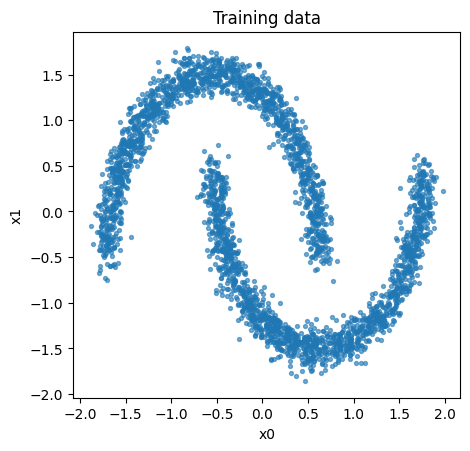

In [4]:
plot_points(x, "Training data")
plt.show()

## Creating the Data Loader

The flow is trained by maximum likelihood. Each batch contains only the coordinates of the data points. There are no labels.

In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset

x_tensor = torch.tensor(x, dtype=torch.float32)
train_dataset = TensorDataset(x_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

## Fitting a Gaussian Baseline

Before implementing the flow, fit a single Gaussian distribution to the data. This baseline captures the global mean and covariance, but it cannot represent the two curved modes.

Fitting the Gaussian distribution to the data in practice means calculating the mean and covariance of the samples ...

In [9]:
mean_gt = x.mean(axis=0)
cov_gt = np.cov(x.T)

In [10]:
baseline_samples = np.random.multivariate_normal(
    mean_gt,
    cov_gt,
    size=3000,
).astype("float32")

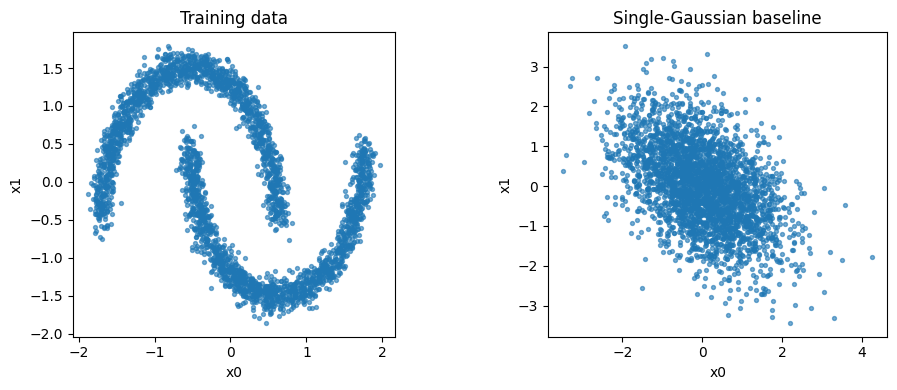

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(baseline_samples, "Single-Gaussian baseline", ax=axes[1])
plt.tight_layout()
plt.show()

The baseline produces an elliptical cloud. It gets the approximate location and spread of the data right, but it fills the empty region between the two moons. The normalizing flow should do better by learning a nonlinear transformation.

## Implementing an Affine Coupling Layer

You now implement the central RealNVP building block. The layer receives a binary mask that decides which coordinate remains fixed and which coordinate is transformed.

The scale network predicts $s(x)$ and the translation network predicts $t(x)$. The scale is passed through a bounded `tanh` nonlinearity to keep early training stable.

In [ ]:
from torch import nn


class AffineCouplingLayer(nn.Module):
    """Affine coupling layer for a two-dimensional RealNVP flow."""

    def __init__(self, mask, hidden_features=64):
        """Intialize the affine coupling layer."""

        super().__init__()

        self.register_buffer(
            "mask", torch.tensor(mask, dtype=torch.float32)
        )  # (1)

        self.scale_net = nn.Sequential(
            nn.Linear(2, hidden_features),
            nn.Tanh(),
            nn.Linear(hidden_features, hidden_features),
            nn.Tanh(),
            nn.Linear(hidden_features, 2),
        )

        self.translate_net = nn.Sequential(
            nn.Linear(2, hidden_features),
            nn.Tanh(),
            nn.Linear(hidden_features, hidden_features),
            nn.Tanh(),
            nn.Linear(hidden_features, 2),
        )

    def forward(self, x):
        """Map data-space variables toward latent-space variables."""

        x_masked = x * self.mask  # (2)

        scale = self.scale_net(x_masked)  # (3) 
        scale = 0.8 * torch.tanh(scale) * (1 - self.mask)  # (4)
        translation = self.translate_net(x_masked) * (1 - self.mask)  # (5)

        z = x_masked + (1 - self.mask) * (x * torch.exp(scale) + translation)
        log_det = scale.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        """Map latent-space variables back to data-space variables."""

        z_masked = z * self.mask

        scale = self.scale_net(z_masked)
        scale = 0.8 * torch.tanh(scale) * (1 - self.mask)
        translation = self.translate_net(z_masked) * (1 - self.mask)

        x = (
            z_masked
            + (1 - self.mask) * ((z - translation) * torch.exp(-scale))
        )

        return x

...

### Checking Invertibility

Before stacking many layers, test one coupling layer. Applying the forward map and then the inverse map should recover the original points up to numerical precision.

In [6]:
test_layer = AffineCouplingLayer(mask=[1, 0])
test_x = torch.randn(5, 2)

test_z, test_log_det = test_layer(test_x)
test_x_reconstructed = test_layer.inverse(test_z)

max_reconstruction_error = (test_x - test_x_reconstructed).abs().max()
print("Maximum reconstruction error:", max_reconstruction_error.item())

Maximum reconstruction error: 1.1920928955078125e-07


The reconstruction error should be very small. This is a useful sanity check: if the inverse does not recover the input, the flow cannot be used reliably for density evaluation or sampling.

## Stacking Coupling Layers into a Flow

A full normalizing flow is a sequence of invertible layers. The forward pass maps data points $x$ to latent points $z$ and accumulates the log determinant of all layers. The inverse pass maps Gaussian latent samples back into data space.

In [7]:
import math


class RealNVP(nn.Module):
    """RealNVP normalizing flow for two-dimensional data."""

    def __init__(self, num_layers=8, hidden_features=64):
        super().__init__()

        masks = []
        for layer_idx in range(num_layers):
            if layer_idx % 2 == 0:
                masks.append([1, 0])
            else:
                masks.append([0, 1])

        self.layers = nn.ModuleList(
            [AffineCouplingLayer(mask, hidden_features) for mask in masks]
        )

    def forward(self, x):
        """Map data samples to latent samples and compute log determinant."""
        z = x
        log_det_total = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_total = log_det_total + log_det

        return z, log_det_total

    def inverse(self, z):
        """Map latent samples to data samples."""
        x = z

        for layer in reversed(self.layers):
            x = layer.inverse(x)

        return x

    def log_prob(self, x):
        """Calculate exact log probability under the flow."""
        z, log_det = self.forward(x)
        log_prob_z = -0.5 * (z.pow(2) + math.log(2 * math.pi)).sum(dim=1)
        return log_prob_z + log_det

    def sample(self, num_samples):
        """Generate samples by transforming Gaussian noise."""
        z = torch.randn(num_samples, 2)
        return self.inverse(z)

## Inspecting the Untrained Flow

Before training, the flow is randomly initialized. Its samples should still look roughly Gaussian or randomly distorted. Training will adjust the coupling layers so that the inverse transformation maps Gaussian samples into the two-moons distribution.

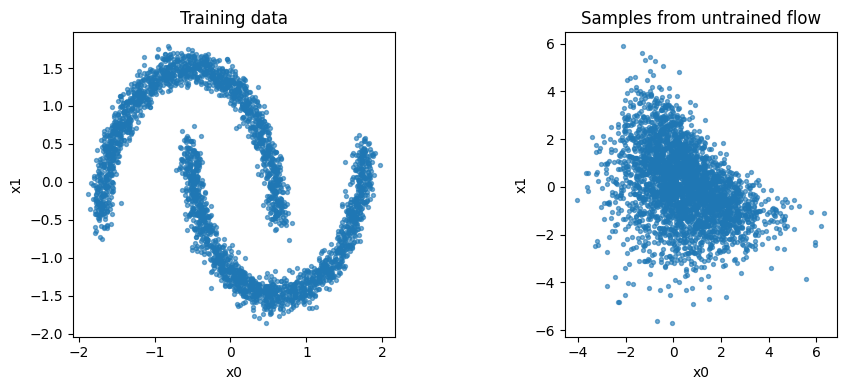

In [8]:
model = RealNVP(num_layers=8, hidden_features=64)

with torch.no_grad():
    untrained_samples = model.sample(3000).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(untrained_samples, "Samples from untrained flow", ax=axes[1])
plt.tight_layout()
plt.show()

The untrained model is not expected to match the data. This plot defines the starting point of the learning process.

## Training by Maximum Likelihood

For each batch, the model maps the data points to latent points and computes their exact log probability. The optimized loss is the negative log-likelihood:
$$
\mathcal{L}
=
-\frac{1}{N}\sum_{i=1}^{N}\log p_X(x_i)
$$
Lower values mean that the model assigns higher probability density to the observed data.

During training, you'll store generated samples at a few epochs. These snapshots will let you inspect how the learned distribution evolves.

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 1500
snapshot_epochs = {0, 10, 25, 50, 200, 600, 1500}

loss_history = []
sample_snapshots = {}
latent_snapshots = {}

for epoch in range(num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    num_seen = 0

    for (x_batch,) in train_loader:
        x_batch = x_batch

        loss = -model.log_prob(x_batch).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.shape[0]
        num_seen += x_batch.shape[0]

    epoch_loss = epoch_loss / num_seen
    loss_history.append(epoch_loss)

    if epoch in snapshot_epochs:
        model.eval()
        with torch.no_grad():
            sample_snapshots[epoch] = model.sample(3000).numpy()
            z_snapshot, _ = model(x_tensor)
            latent_snapshots[epoch] = z_snapshot.numpy()

    if epoch % 250 == 0:
        print(f"Epoch {epoch:4d} | negative log-likelihood = {epoch_loss:.4f}")

Epoch    0 | negative log-likelihood = 2.7915
Epoch  250 | negative log-likelihood = 1.3801
Epoch  500 | negative log-likelihood = 1.3495
Epoch  750 | negative log-likelihood = 1.3497
Epoch 1000 | negative log-likelihood = 1.3368
Epoch 1250 | negative log-likelihood = 1.3398
Epoch 1500 | negative log-likelihood = 1.3233


## Plotting the Training Curve

The negative log-likelihood should generally decrease, although it may not be perfectly monotonic because training uses mini-batches and stochastic optimization.

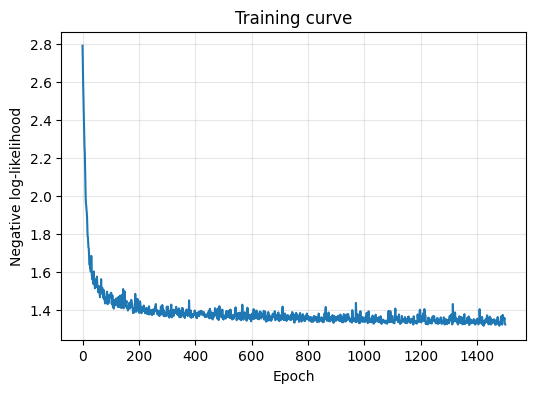

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative log-likelihood")
plt.title("Training curve")
plt.grid(True, alpha=0.3)
plt.show()

## Comparing Samples Before and After Training

The most direct way to inspect the learned generative model is to sample from it. The trained flow should transform Gaussian latent samples into points that concentrate along the two moons.

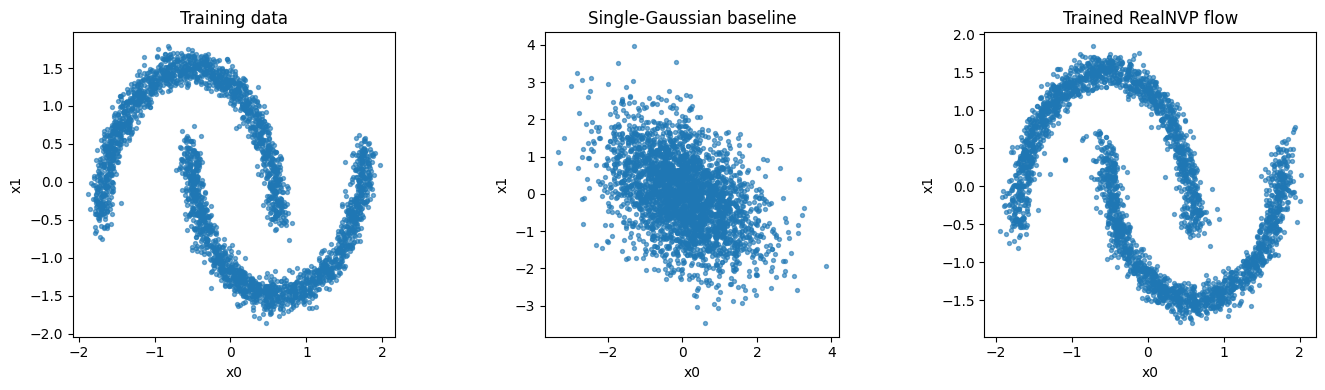

In [11]:
model.eval()
with torch.no_grad():
    trained_samples = model.sample(3000).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_points(x, "Training data", ax=axes[0])
plot_points(baseline_samples, "Single-Gaussian baseline", ax=axes[1])
plot_points(trained_samples, "Trained RealNVP flow", ax=axes[2])
plt.tight_layout()
plt.show()

The baseline captures only the overall elliptical spread. The flow should better capture the curved high-density regions and should place fewer samples in the empty region between the moons.

## Visualizing the Learning Process

The snapshots below show generated samples from the inverse flow during training. Early samples are poorly organized. As training progresses, the model gradually bends the Gaussian into the target distribution.

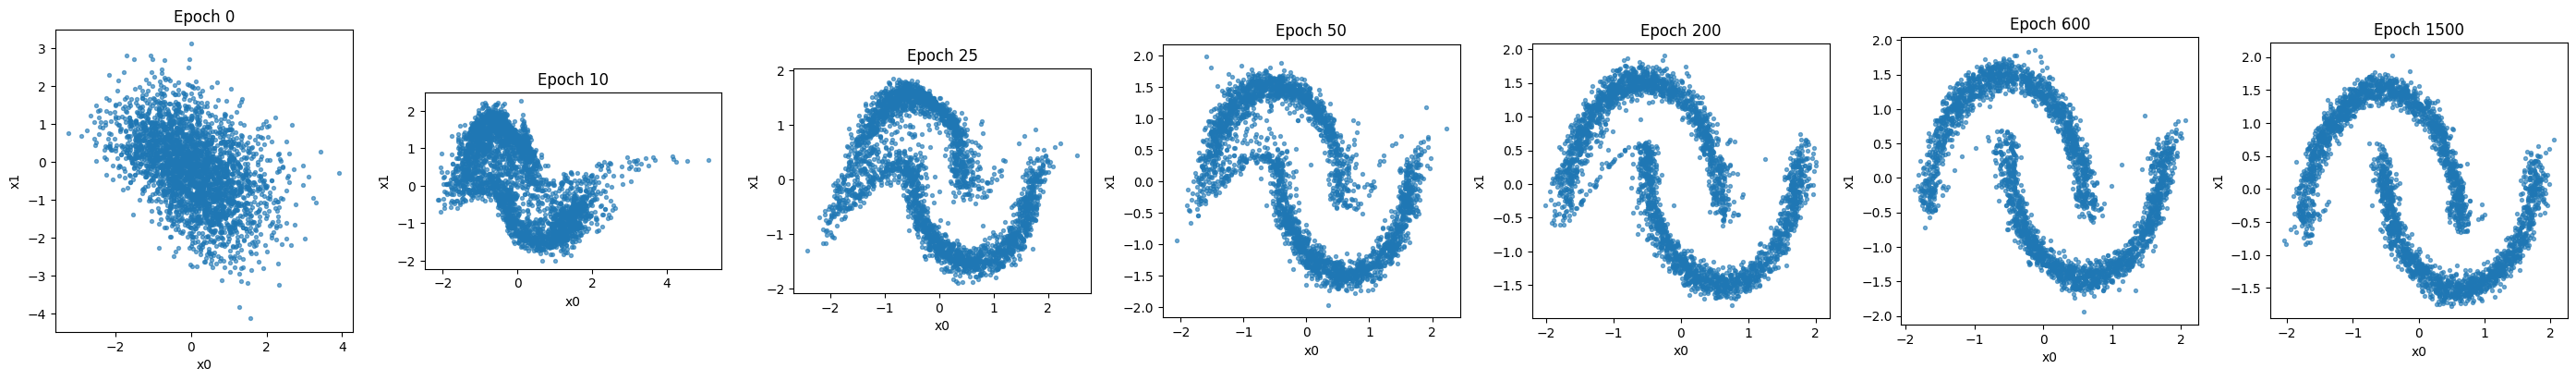

In [12]:
fig, axes = plt.subplots(
    1, len(sample_snapshots), figsize=(4 * len(sample_snapshots), 4)
)

for ax, epoch in zip(axes, sorted(sample_snapshots)):
    plot_points(sample_snapshots[epoch], f"Epoch {epoch}", ax=ax)

plt.tight_layout()
plt.show()

## Inspecting the Latent Space

A trained flow should also map the data distribution back to something close to a standard Gaussian. This is the forward direction of the model:
$$
x \rightarrow z
$$
If training worked, the two curved moons should become a compact, approximately Gaussian cloud in latent space.

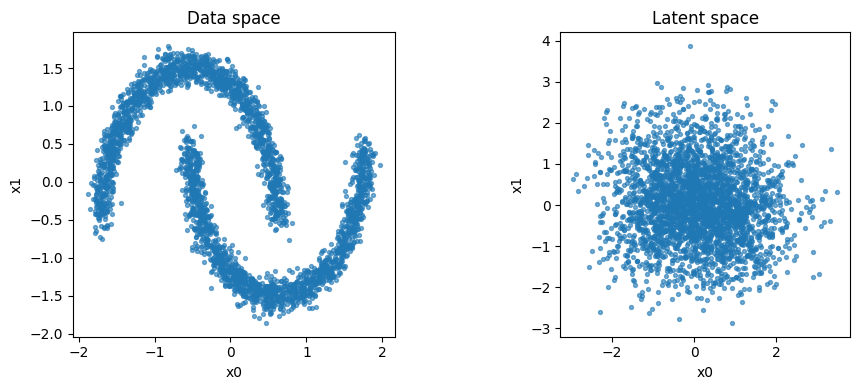

Latent mean: [0.06440308 0.05145434]
Latent standard deviation: [1.02444    0.96629745]


In [13]:
with torch.no_grad():
    z_p, _ = model(x_tensor)
    z_p = z_p.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_points(x, "Data space", ax=axes[0])
plot_points(z_p, "Latent space", ax=axes[1])
plt.tight_layout()
plt.show()

print("Latent mean:", z_p.mean(axis=0))
print("Latent standard deviation:", z_p.std(axis=0))

The latent points do not need to form a perfect Gaussian, especially for a small model trained briefly. Still, they should be much less curved and more compact than the original data distribution.

## Evaluating Against the Gaussian Baseline

Because normalizing flows provide exact likelihoods, you can compare the average negative log-likelihood of the trained flow with that of the fitted Gaussian baseline.

This comparison is not the only way to evaluate generative models, but it is a natural one here because likelihood is the quantity the flow optimizes directly.

In [14]:
def gaussian_log_prob(points, mean, cov):
    """Calculate log probability under a fitted multivariate Gaussian."""
    dim = points.shape[1]
    centered = points - mean
    inv_cov = np.linalg.inv(cov)
    log_det_cov = np.linalg.slogdet(cov)[1]

    quadratic = np.sum(centered @ inv_cov * centered, axis=1)
    return -0.5 * (dim * np.log(2 * np.pi) + log_det_cov + quadratic)


baseline_nll = -gaussian_log_prob(x, mean_gt, cov_gt).mean()

model.eval()
with torch.no_grad():
    flow_nll = -model.log_prob(x_tensor).mean().item()

print(f"Single-Gaussian baseline NLL: {baseline_nll:.4f}")
print(f"RealNVP flow NLL:             {flow_nll:.4f}")

Single-Gaussian baseline NLL: 2.7268
RealNVP flow NLL:             1.3247


The flow should typically achieve a lower negative log-likelihood than the single Gaussian baseline. This means that it assigns higher probability density to the observed data.

Do not overinterpret small numerical differences between runs. The model is stochastic, and short training runs may vary. The qualitative comparison of samples and latent-space structure is equally important in this educational example.

## Visualizing the Learned Density

Since the data are two-dimensional, you can evaluate the learned log probability on a grid and plot it as a density map. This gives a more complete picture than samples alone.

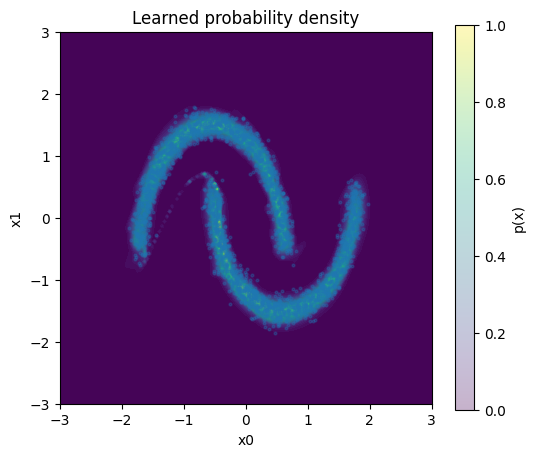

In [15]:
def evaluate_log_prob_on_grid(model, xlim=(-3, 3), ylim=(-3, 3), num_points=150):
    """Evaluate flow log probability on a two-dimensional grid."""
    x0 = np.linspace(xlim[0], xlim[1], num_points)
    x1 = np.linspace(ylim[0], ylim[1], num_points)
    grid_x0, grid_x1 = np.meshgrid(x0, x1)
    grid = np.stack([grid_x0.ravel(), grid_x1.ravel()], axis=1).astype("float32")

    grid_tensor = torch.tensor(grid)

    model.eval()
    with torch.no_grad():
        log_prob = model.log_prob(grid_tensor).numpy()

    log_prob = log_prob.reshape(num_points, num_points)
    return x0, x1, log_prob


x0_grid, x1_grid, log_prob_grid = evaluate_log_prob_on_grid(model)

plt.figure(figsize=(6, 5))
plt.contourf(x0_grid, x1_grid, np.exp(log_prob_grid), levels=50)
plt.scatter(x[:, 0], x[:, 1], s=4, alpha=0.3)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Learned probability density")
plt.colorbar(label="p(x)")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

The high-density regions should align with the two moons. This plot is often the clearest demonstration that a normalizing flow is not merely producing plausible samples; it is learning a probability density over the data space.

## Testing the Inverse Consistency of the Full Flow

As a final sanity check, apply the full flow forward and then backward. The reconstructed points should match the original input points up to small numerical errors.

In [16]:
model.eval()
with torch.no_grad():
    x_test = x_tensor[:10]
    z_test, _ = model(x_test)
    x_reconstructed = model.inverse(z_test)

reconstruction_error = (x_test - x_reconstructed).abs().max().item()
print("Maximum reconstruction error:", reconstruction_error)

Maximum reconstruction error: 2.384185791015625e-07


This near-zero reconstruction error is specific to invertible models. A standard encoder-decoder may reconstruct inputs approximately, but a normalizing flow is designed so that the inverse transformation is exact up to floating-point precision.

## Limitations

Normalizing flows are elegant, but they also have important limitations.

First, invertibility restricts the architecture. You cannot use arbitrary neural-network layers if they destroy information or make the Jacobian determinant intractable.

Second, the model dimension is fixed. The latent variable and the data must have the same dimensionality. This differs from autoencoders, where the latent space can be lower-dimensional.

Third, likelihood and sample quality do not always agree perfectly, especially in high-dimensional data such as natural images.

Fourth, simple coupling-layer flows may struggle with very complex distributions unless many layers, stronger transformations, or more advanced architectures are used.

Finally, while flows can sample faster than diffusion models, they may be less flexible than state-of-the-art diffusion models for high-resolution image generation.

## Exercises

### Exploring the Current Example

1. Change the number of coupling layers. Try `num_layers=2`, `num_layers=4`, and `num_layers=12`. How does the learned distribution change?

2. Change the hidden size of the scale and translation networks. What happens when `hidden_features` is too small?

3. Increase or decrease the noise in the two-moons dataset. How does noise affect the learned density?

4. Train for fewer epochs and inspect the snapshots. At what point does the distribution begin to resemble two moons?

### Extending the Data Distribution

5. Replace the two-moons data with concentric rings, a spiral, or a mixture of Gaussians.

6. Compare the flow against a Gaussian mixture baseline instead of a single Gaussian.

7. Plot the latent-space representation for each new dataset. Does the flow map the data back to an approximately Gaussian distribution?

### Going Beyond the Notebook

8. Implement a conditional normalizing flow that receives a class label as an additional input.

9. Add a simple permutation or rotation between coupling layers and compare it with the alternating-mask version.

10. Try an image dataset only after the two-dimensional version works. What additional architectural constraints appear when the dimensionality increases?

## Further Readings

Dinh, L., Sohl-Dickstein, J., and Bengio, S. (2017). *Density Estimation Using Real NVP*.

Rezende, D. J., and Mohamed, S. (2015). *Variational Inference with Normalizing Flows*.

Papamakarios, G., Nalisnick, E., Rezende, D. J., Mohamed, S., and Lakshminarayanan, B. (2021). *Normalizing Flows for Probabilistic Modeling and Inference*.